In [7]:
import json
import os
import glob
import pandas as pd
from Bio.Seq import Seq
from Bio import SeqIO
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator
import seaborn as sns
from augur.utils import json_to_tree
import baltic as bt

## compare dA/dt, dN/dt and dS/dt between human and avian H1 and H3

In [8]:
avian_lineages = ['H1a', 'H1b', 'H3a', 'H3b', 'H3c']

In [9]:
# read in nonsyn and syn rates (avian calculated in `calc_avian_dNdt_and_dSdt.ipynb`)
# human rates calculated for a different project, results copied here

avian_rates_df = pd.read_csv(f'Supplement-AvianHArates/rates_results/avian_rates_from_ref.tsv', sep='\t')
human_rates_df = pd.read_csv(f'Supplement-AvianHArates/rates_results/human_rates_from_ref.tsv', sep='\t')

In [10]:
# read in adaptation results

human_adaptation_df = pd.read_csv(f'Supplement-AvianHArates/rates_results/human_full_spikeHA_adaptation_rates.tsv', sep='\t')


avian_adaptation_results = []
for l in avian_lineages:
    filename = f'Supplement-AvianHArates/adaptation_results/results/avian{l}_ha_3_5_75_adaptation.json'
    with open(filename, 'r') as f:
        adaptation_results = json.load(f)
        avian_adaptation_results.append({'virus': l[:-1], 'lineage': l, 
                                         'gene': 'ha', 
                                         'rate_of_adaptation': adaptation_results['rate_of_adaptation']})
        
avian_adaptation_df = pd.DataFrame(avian_adaptation_results)

In [11]:
legible_names = {'h1n1pdm': 'A/H1N1pdm', 'h3n2': 'A/H3N2', 'vic': 'B/Vic', 'yam': 'B/Yam',
                 'H1a': 'avian H1a', 'H1b': 'avian H1b', 
                 'H3a': 'avian H3a', 'H3b':'avian H3b', 'H3c': 'avian H3c'}

In [13]:
all_viruses= ['h1n1pdm', 'h3n2', 'vic', 'yam', 'H1a', 'H1b', 'H3a', 'H3b', 'H3c']

In [43]:
def trees_to_baltic(virus):

    nextstrainPath= f'../nextstrain_builds/avian-separate-lineages/data/full_ha_type_trees/{virus}.json'
    json_translation={'absoluteTime':lambda k: k.traits['node_attrs']['num_date']['value'],
                      'name':'name'}
    tree, metadata = bt.loadJSON(nextstrainPath,json_translation=json_translation)
    
    return tree

In [44]:
lineage_ancestral_node = {'H1': ['NODE_0000288', 'NODE_0000268'], 
                          'H3': ['NODE_0000889','NODE_0000499','NODE_0000483']}

In [45]:
# give each lineage within the HA type a letter
lineage_letters = {'H1': {'NODE_0000288': 'a', 'NODE_0000268': 'b'}, 
                          'H3': {'NODE_0000889': 'a', 'NODE_0000499': 'b', 'NODE_0000483': 'c'}}

In [111]:
# color per lineage
cmap_lineage = {'NODE_0000288': '#0189e0', 'NODE_0000268': '#31aefe', 
                'NODE_0000889': '#5f3496','NODE_0000499': '#8554c4','NODE_0000483': '#9a71ce'}

In [61]:
def get_nodes_per_lineage(virus):
    """
    Given the common ancestor of the lienage, find all tips and internal branches that are in the lineage
    """

    tree_file = f'../nextstrain_builds/avian-separate-lineages/data/full_ha_type_trees/{virus}.json'

    #read in the tree
    with open(tree_file, 'r') as f:
        tree_json = json.load(f)

    #put tree in Bio.phylo format
    tree = json_to_tree(tree_json)
    
    ancestral_nodes = lineage_ancestral_node[virus]
    
    nodes_per_lineage = {x:[] for x in ancestral_nodes}
    lineage_to_node_mapper = {}
    
    for node in tree.find_clades():
        # see if one of the lineage ancestral nodes is between this node and the root
        path_to_root = [x.name for x in tree.get_path(node)]
        
        has_ancestor = set(ancestral_nodes) & set(path_to_root)
        
        if len(has_ancestor)!=0:
            lin_ancestor = list(has_ancestor)[0]
            nodes_per_lineage[lin_ancestor].append(node.name)
            lineage_to_node_mapper[node.name] = lin_ancestor

            
    return nodes_per_lineage, lineage_to_node_mapper

In [115]:
def plot_tree(virus, ax):
    """
    Draw the tree for each avian HA type using baltic
    
    Color by lineage
    """

    
    tree = trees_to_baltic(virus)
    
    nodes_per_lineage, lineage_to_node_mapper = get_nodes_per_lineage(virus)
    
    branchWidth=1
    branch_color = '#808080'
    tipSize= 4


    # k objects are tips, nodes, branches
    for k in tree.Objects: ## iterate over objects in tree
        y=k.y ## or use absolute time instead
        x=k.absoluteTime
        node_name = k.name
        if node_name in lineage_to_node_mapper.keys():
            color = cmap_lineage[lineage_to_node_mapper[node_name]]
        else:
            color = '#d3d3d3'


        if x==None: ## matplotlib won't plot Nones, like root
            x=0.0
        if 'node_attrs' in k.parent.traits:
            xp=k.parent.absoluteTime ## get x position of current object's parent
        else:
            xp = x

        if isinstance(k,bt.leaf) or k.branchType=='leaf': ## if leaf...
            m = "."
            ax.scatter(x,y, s=tipSize, facecolor=color, 
                       linewidth=0.5, marker=m, zorder=3) ## plot circle for every tip

        
        #plot the vertical lines
        elif isinstance(k,bt.node) or k.branchType=='node': ## if node...
            ax.plot([x,x],[k.children[-1].y, k.children[0].y], lw=branchWidth, color=color, ls='-',zorder=1) 
        
        #plot the branches
        ax.plot([xp,x],[y,y],lw=branchWidth,color=color,ls='-',zorder=1)


    ax.spines['left'].set_color('white')
    ax.spines['top'].set_color('white')
    ax.spines['right'].set_color('white')
    ax.tick_params(axis='x', labelsize=12)
    ax.set_yticks([])
    
    ax.text(0.02, 0.1, f'Avian {virus}', fontsize=12, transform=ax.transAxes)
    
    if virus == 'H3':
        ax.text(0.5, 0.75, 'H3c', color = '#9a71ce', fontsize=12, transform=ax.transAxes)
        ax.text(0.6, 0.4, 'H3b', color = '#8554c4', fontsize=12, transform=ax.transAxes)
        ax.text(0.55, 0.15, 'H3a', color = '#5f3496', fontsize=12, transform=ax.transAxes)
    elif virus == 'H1':
        ax.text(0.5, 0.2, 'H1a', color = '#0189e0', fontsize=12, transform=ax.transAxes)
        ax.text(0.4, 0.8, 'H1b', color = '#31aefe', fontsize=12, transform=ax.transAxes)
        
        
    

    
    return ax



In [88]:
cmap = {'h1n1pdm': '#ceecff', 'h3n2': '#ddcfee', 'vic': '#ffa989', 'yam': '#fde091',
                 'H1a': '#45b6fe', 'H1b': '#45b6fe', 
                 'H3a': '#6C3BAA', 'H3b':'#6C3BAA', 'H3c': '#6C3BAA'}

In [97]:
def plot_human_vs_avian_HA_rate_comparisons(filename=None):
    """
    """
    #plot styling
    sns.set_style("white")
    plt.rcParams['figure.dpi']= 300
    plt.rcParams['font.family'] = 'Arial'
    
    to_plot_da_dn_ds = []
        
    for h_virus in ['h1n1pdm', 'h3n2', 'vic', 'yam']:
        virus_df = human_rates_df[human_rates_df['virus']==h_virus]
        ha_df = virus_df[virus_df['gene']=='ha']
        syn_rate = ha_df[ha_df['mut_type']=='syn']['rate_per_nt'].item()
        nonsyn_rate = ha_df[ha_df['mut_type']=='nonsyn']['rate_per_nt'].item()
        
        adaptation_rate = human_adaptation_df[human_adaptation_df['virus']==h_virus]['adaptation_rate'].item()

        to_plot_da_dn_ds.append({'virus': h_virus, 'host': 'human', 
                              'ha_syn_rate': syn_rate, 'ha_nonsyn_rate': nonsyn_rate, 
                                 'ha_adaptation_rate': adaptation_rate})
        
    for a_virus in ['H1a', 'H1b', 'H3a', 'H3b', 'H3c']:
        virus_df = avian_rates_df[avian_rates_df['virus']==f'avian{a_virus}']
        ha_df = virus_df[virus_df['gene']=='ha']
        syn_rate = ha_df[ha_df['mut_type']=='syn']['rate_per_nt'].item()
        nonsyn_rate = ha_df[ha_df['mut_type']=='nonsyn']['rate_per_nt'].item()
        
        adaptation_rate = avian_adaptation_df[avian_adaptation_df['lineage']==a_virus]['rate_of_adaptation'].item()

        to_plot_da_dn_ds.append({'virus': a_virus, 'host': 'avian', 
                              'ha_syn_rate': syn_rate, 'ha_nonsyn_rate': nonsyn_rate, 
                                 'ha_adaptation_rate':adaptation_rate})
        
    
    da_dn_ds_df = pd.DataFrame(to_plot_da_dn_ds)
    
    #plot styling
    sns.set_style("white")
    plt.rcParams['figure.dpi']= 300
    plt.rcParams['font.family'] = 'Arial'
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(8,6), gridspec_kw={'height_ratios':[0.7,1]})
    
    plot_tree('H1', ax1)
    plot_tree('H3', ax2)
    
    for v in all_viruses:
        leg_name = legible_names[v]

        df_v = da_dn_ds_df[da_dn_ds_df['virus']==v]
        ax3.scatter(y=df_v['ha_nonsyn_rate'], x=df_v['ha_syn_rate'], s=80, color=cmap[v])

        ax3.annotate(leg_name, (df_v['ha_syn_rate']+0.0001+manual_adjustments_v['x'][v], 
                         df_v['ha_nonsyn_rate']-0.000005+manual_adjustments_v['y'][v]), 
                     fontsize=8) 


        ax4.scatter(x=df_v['ha_nonsyn_rate'], y= df_v['ha_adaptation_rate'], s=80, color=cmap[v])
        if v in ['H3a']:
            ax4.annotate(
                leg_name,
                xy=(df_v['ha_nonsyn_rate'], df_v['ha_adaptation_rate'] + 0.00005),  # point to annotate
                xytext=(
                    df_v['ha_nonsyn_rate'] + manual_adjustments_va['x'][v],
                    df_v['ha_adaptation_rate'] + manual_adjustments_va['y'][v]
                ),  # location of text
                fontsize=8,
                arrowprops=dict(arrowstyle="-", color="black", lw=0.5)  # line from point to text
            )
        else:
            ax4.annotate(leg_name, (df_v['ha_nonsyn_rate']+0.00008+manual_adjustments_va['x'][v], 
                             df_v['ha_adaptation_rate']-0.000006+manual_adjustments_va['y'][v]), 
                         fontsize=8) 
            

    # figure panel labels
    ax1.text(-0.35, 0.98, 'A', fontsize=16, transform=ax1.transAxes) 
    ax2.text(-0.3, 0.98, 'B', fontsize=16, transform=ax2.transAxes) 
    ax3.text(-0.35, 0.98, 'C', fontsize=16, transform=ax3.transAxes) 
    ax4.text(-0.3, 0.98, 'D', fontsize=16, transform=ax4.transAxes) 
    
    # axis labels
    ax3.set_ylabel('HA dN/dt')
    ax3.set_xlabel('HA dS/dt')
    ax4.set_xlabel('HA dN/dt')
    ax4.set_ylabel('HA dA/dt')
    
    # add a legend
    ax3.legend(handles=[Line2D([0], [0], marker='o', color='w', label='Human',
                               markerfacecolor='#d3d3d3', markersize=10), 
                        Line2D([0], [0], marker='o', color='w', label='Avian',
                               markerfacecolor='#808080', markersize=10)],
              bbox_to_anchor=(0.45,0.98), fontsize=8,title_fontsize=8, title = 'Viral host species', 
               bbox_transform = ax3.transAxes)
    
    
    fig.subplots_adjust(wspace=0.4)



    sns.despine()
    
    if filename:
        fig.savefig(filename, dpi=300, bbox_inches='tight')

In [119]:
manual_adjustments_v = {'x': {v:0.0 for v in all_viruses}, 
                        'y': {v:0.0 for v in all_viruses}}
manual_adjustments_va = {'x': {v:0.0 for v in all_viruses}, 
                        'y': {v:0.0 for v in all_viruses}}

manual_adjustments_v['x']['H1a'] = -0.00025
manual_adjustments_v['y']['H1a'] = -0.00012
manual_adjustments_v['x']['H1b'] = -0.00025
manual_adjustments_v['y']['H1b'] = -0.00012
manual_adjustments_v['x']['H3c'] = -0.00025
manual_adjustments_v['y']['H3c'] = 0.0001

manual_adjustments_va['y']['H1a'] = -0.00008
manual_adjustments_va['y']['H1b'] = 0.00003
manual_adjustments_va['y']['H3b'] = -0.00008
manual_adjustments_va['x']['H3b'] = 0.00006
manual_adjustments_va['x']['H3c'] = 0.00004
manual_adjustments_va['y']['H3a'] = 0.00045
manual_adjustments_va['y']['H3c'] = -0.00003
manual_adjustments_va['x']['H3a'] = -0.00008



Tree height: 68.692708
Tree length: 1413.153674
annotations present

Numbers of objects in tree: 1577 (678 nodes and 899 leaves)


Tree height: 180.252135
Tree length: 4576.572575
annotations present

Numbers of objects in tree: 2318 (1034 nodes and 1284 leaves)



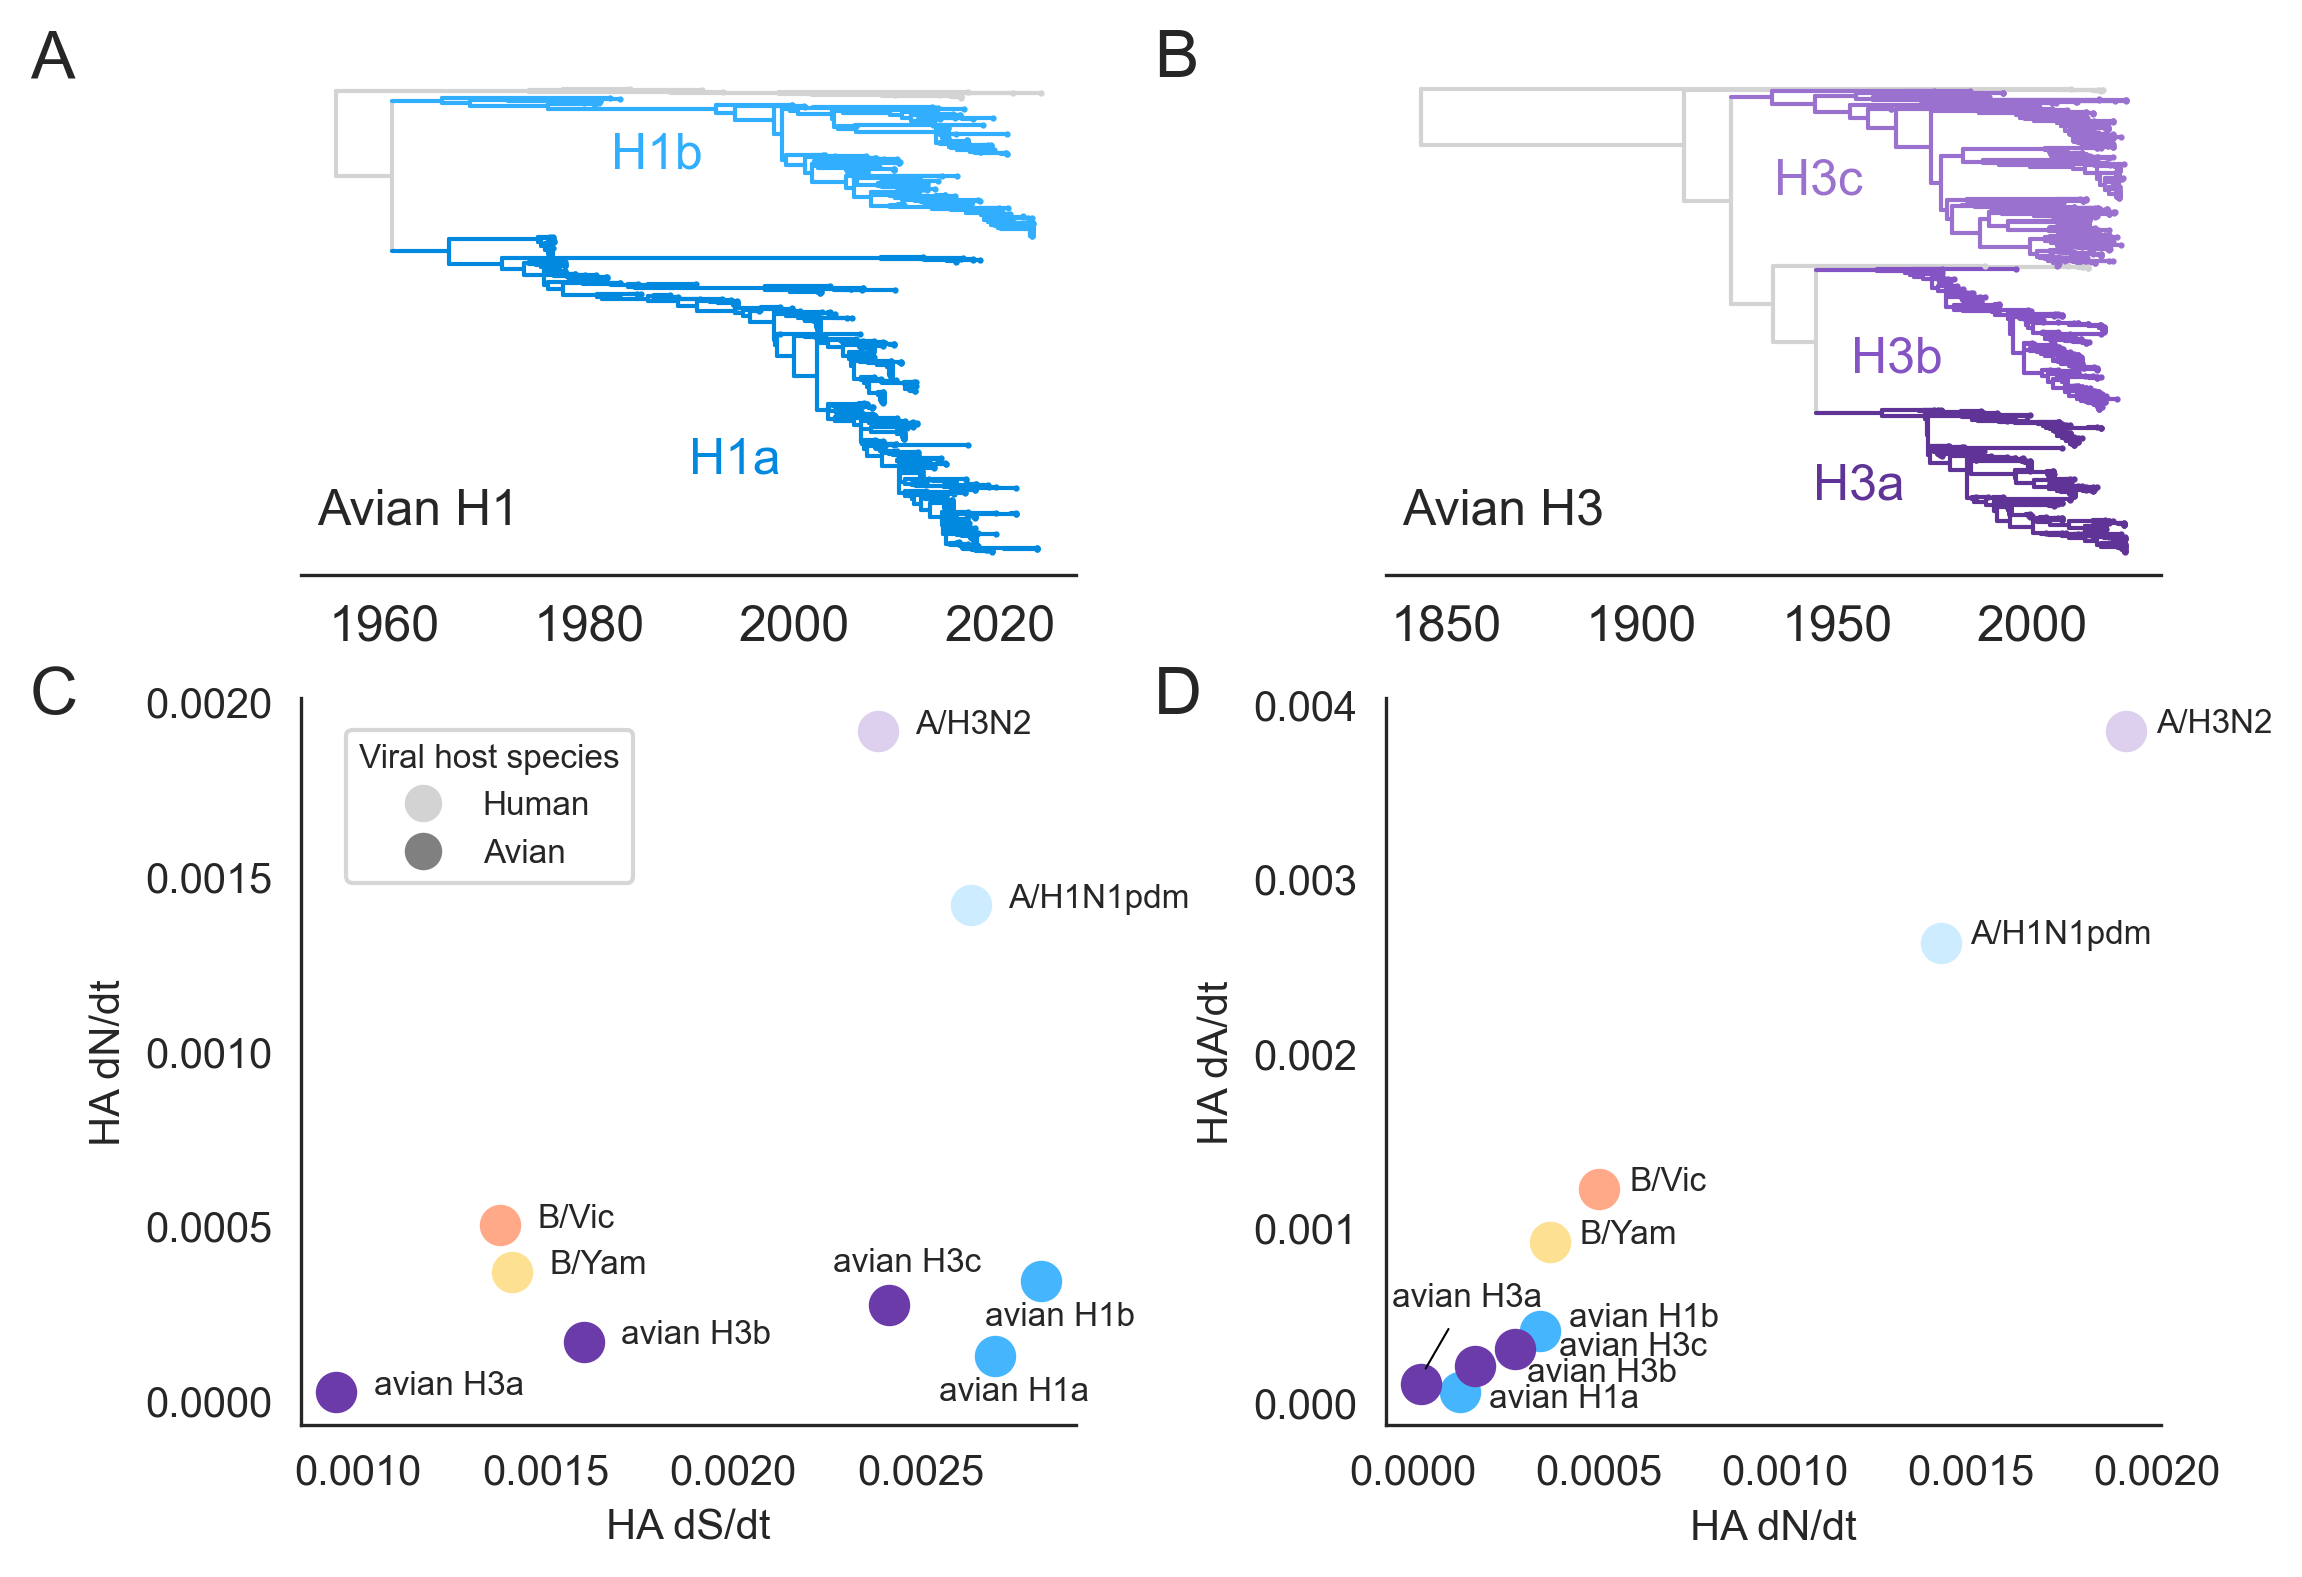

In [120]:
plot_human_vs_avian_HA_rate_comparisons(filename = 'Supplement-AvianHArates/human_vs_avian_rates.png')